Analiz verisi okundu.
Satır sayısı: 300

Korelasyon matrisi oluşturuldu.
Dosya: korelasyon_matrisi.xlsx


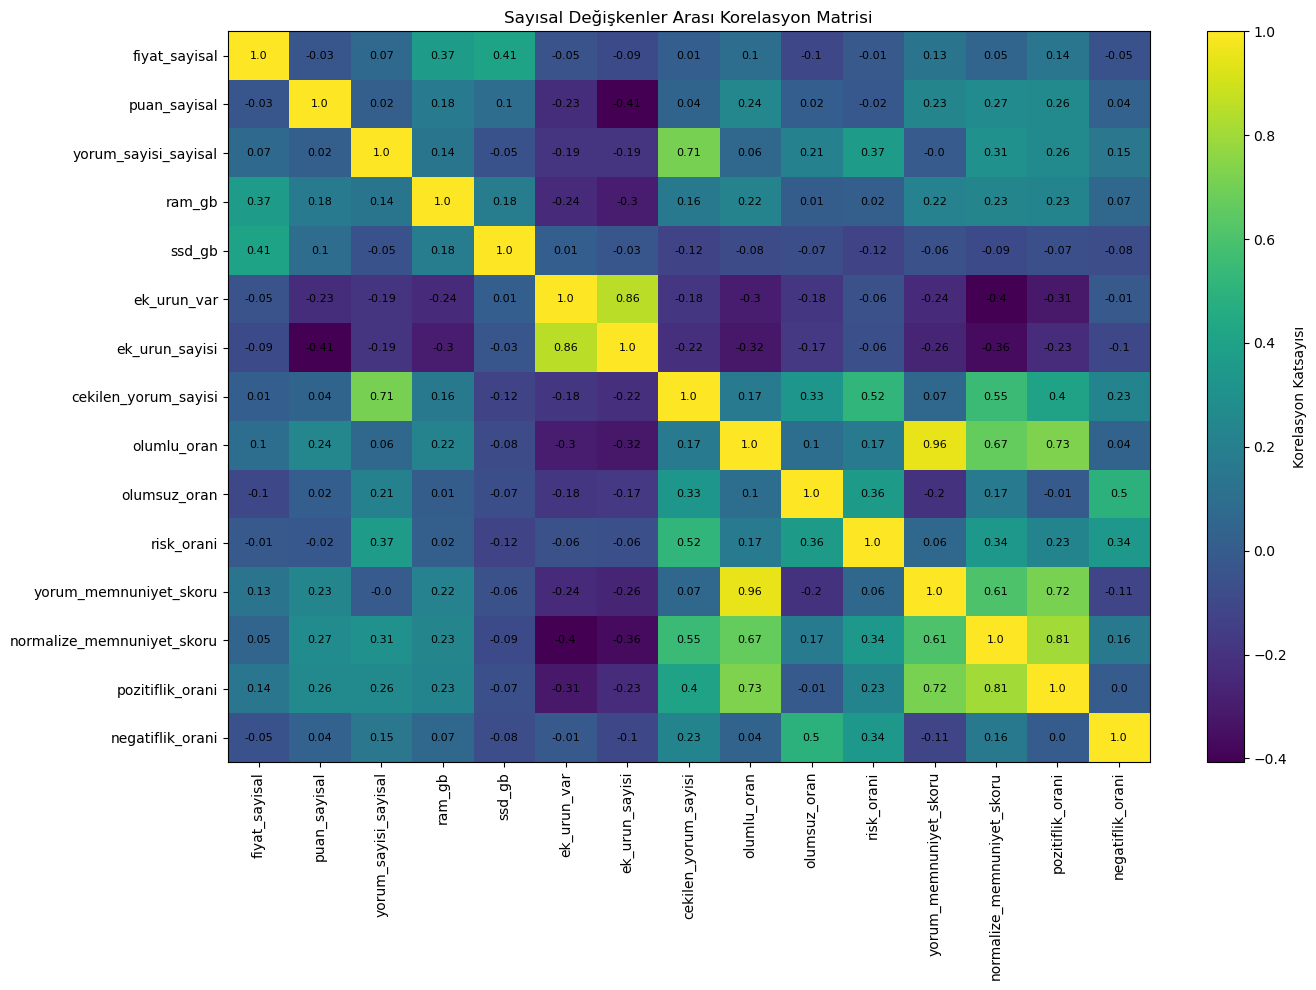

Önemli korelasyonlar dosyası oluşturuldu:
onemli_korelasyonlar.xlsx

En güçlü ilk 10 ilişki:
                     degisken_1                  degisken_2  korelasyon  \
173      yorum_memnuniyet_skoru                 olumlu_oran    0.955041   
81                  ek_urun_var              ek_urun_sayisi    0.855354   
193  normalize_memnuniyet_skoru            pozitiflik_orani    0.806388   
203            pozitiflik_orani                 olumlu_oran    0.725371   
206            pozitiflik_orani      yorum_memnuniyet_skoru    0.717463   
107        cekilen_yorum_sayisi        yorum_sayisi_sayisal    0.713686   
188  normalize_memnuniyet_skoru                 olumlu_oran    0.668404   
177      yorum_memnuniyet_skoru  normalize_memnuniyet_skoru    0.607345   
187  normalize_memnuniyet_skoru        cekilen_yorum_sayisi    0.552636   
157                  risk_orani        cekilen_yorum_sayisi    0.520617   

     abs_korelasyon  
173        0.955041  
81         0.855354  
193        0.80

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==============================
# DOSYA AYARLARI
# ==============================

GIRIS_DOSYASI = "analiz_verisi.xlsx"
CIKTI_KLASORU = "grafikler"

os.makedirs(CIKTI_KLASORU, exist_ok=True)

df = pd.read_excel(GIRIS_DOSYASI)

print("Analiz verisi okundu.")
print("Satır sayısı:", len(df))


# ==============================
# KORELASYONDA KULLANILACAK SÜTUNLAR
# ==============================

korelasyon_sutunlari = [
    "fiyat_sayisal",
    "puan_sayisal",
    "yorum_sayisi_sayisal",
    "ram_gb",
    "ssd_gb",
    "ek_urun_var",
    "ek_urun_sayisi",
    "cekilen_yorum_sayisi",
    "olumlu_oran",
    "olumsuz_oran",
    "risk_orani",
    "yorum_memnuniyet_skoru",
    "normalize_memnuniyet_skoru",
    "pozitiflik_orani",
    "negatiflik_orani"
]

# Dosyada olmayan sütunları otomatik çıkar
korelasyon_sutunlari = [
    col for col in korelasyon_sutunlari if col in df.columns
]

corr_df = df[korelasyon_sutunlari].copy()

# Eksik sayısal değerleri 0 ile doldur
corr_df = corr_df.fillna(0)


# ==============================
# KORELASYON MATRİSİ
# ==============================

corr_matrix = corr_df.corr()

corr_matrix.to_excel("korelasyon_matrisi.xlsx")

print("\nKorelasyon matrisi oluşturuldu.")
print("Dosya: korelasyon_matrisi.xlsx")


# ==============================
# ISI HARİTASI
# ==============================

plt.figure(figsize=(14, 10))

plt.imshow(corr_matrix, aspect="auto")

plt.colorbar(label="Korelasyon Katsayısı")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index
)

plt.title("Sayısal Değişkenler Arası Korelasyon Matrisi")

# Hücrelere değerleri yaz
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            round(corr_matrix.iloc[i, j], 2),
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()

plt.savefig(
    f"{CIKTI_KLASORU}/korelasyon_isi_haritasi.png",
    dpi=300
)

plt.show()


# ==============================
# ÖNEMLİ KORELASYONLARI LİSTELE
# ==============================

corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ["degisken_1", "degisken_2", "korelasyon"]

# Aynı değişkenleri ve tekrarları çıkar
corr_pairs = corr_pairs[
    corr_pairs["degisken_1"] != corr_pairs["degisken_2"]
]

corr_pairs["abs_korelasyon"] = corr_pairs["korelasyon"].abs()

corr_pairs = corr_pairs.sort_values(
    by="abs_korelasyon",
    ascending=False
)

corr_pairs = corr_pairs.drop_duplicates(
    subset=["abs_korelasyon"]
)

corr_pairs.to_excel(
    "onemli_korelasyonlar.xlsx",
    index=False
)

print("Önemli korelasyonlar dosyası oluşturuldu:")
print("onemli_korelasyonlar.xlsx")

print("\nEn güçlü ilk 10 ilişki:")
print(corr_pairs.head(10))